> **🤖 AI-coded.** This notebook is part of an **AI-coded extension of [Dynestyx](https://github.com/BasisResearch/dynestyx)** that adds factorial state-space models (fSSMs) — a `dynestyx`-based counterpart to [`cuthberto-carlos`](https://github.com/state-space-models/cuthberto-carlos), built on [`cuthbert`](https://github.com/state-space-models/cuthbert). It reproduces the online skill-rating models of [Duffield et al. (2024)](https://doi.org/10.1093/jrsssc/qlae035). See the [project README](https://github.com/DanWaxman/dynestyx) for an overview.

# Reproducing Duffield et al. (2024) — Football (EPL)

This deep dive reproduces the **football** results of

> Duffield, Power, Wadsworth et al. (2024), *A state-space perspective on modelling and inference for online skill rating*, **JRSS-C 73(5):1262–1282** ([code: `SamDuffield/abile`](https://github.com/SamDuffield/abile)),

with dynestyx, rating **English Premier League** teams over 2018–2022. Football is where the paper makes its **model-refinement** point, so we fit *two* models:

1. **Outcome model** — scalar team skill, win/draw/loss via `MatchOutcomeObservation` (their Elo–Davidson SSM). Paper Table 2 EPL test NLL: **0.988**.
2. **Bivariate-Poisson scoreline model** — a 2-D *attack/defense* skill per team and a bivariate-Poisson goal likelihood (`BivariatePoissonScoreObservation`). Modelling the *scoreline* gives **better win/draw/loss predictions** (paper test W/D/L NLL: EKF **0.975**, SMC **0.978**) despite not being trained for that objective.

Data is public ([football-data.co.uk](https://www.football-data.co.uk)) and downloaded at runtime.


In [1]:
import io, time, urllib.request
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpyro.distributions as dist
import optax

jax.config.update("jax_enable_x64", True)

from dynestyx import (
    FactorialDynamicalModel, MatchOutcomeObservation, BivariatePoissonScoreObservation,
    RandomWalkEvolution, FactorialEKFConfig, FactorialPFConfig,
)
from dynestyx.inference.integrations.cuthbert.factorial_filter import compute_factorial_filter
from dynestyx.contrib import outcome_predictive_probs, score_predictive, split_nll

## 1. Data

We mirror abile's loader: EPL season CSVs (`E0.csv`) for 2018/19–2021/22, time in **days** from the 2018-07-30 origin, two factors per match `[home, away]`, and goals `(FTHG, FTAG)`.


In [2]:
def fetch_csv(url, tries=5):
    for t in range(tries):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=90) as r:
                return io.BytesIO(r.read())
        except Exception:
            if t == tries - 1:
                raise
            time.sleep(4)

ORIGIN = pd.to_datetime("2018-07-30")
cols = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]
frames = []
for yr in range(2018, 2022):
    a, b = str(yr)[-2:], str(yr + 1)[-2:]
    frames.append(pd.read_csv(fetch_csv(f"https://www.football-data.co.uk/mmz4281/{a}{b}/E0.csv"))[cols])
data = pd.concat(frames, ignore_index=True).dropna()
data["Timestamp"] = pd.to_datetime(data["Date"], dayfirst=True)
data["TimestampDays"] = (data["Timestamp"] - ORIGIN).dt.days
teams = sorted(pd.unique(pd.concat([data["HomeTeam"], data["AwayTeam"]])))
name_to_id = {a: i for i, a in enumerate(teams)}
id_to_name = {i: a for a, i in name_to_id.items()}
data = data[(data["Timestamp"] > ORIGIN) & (data["Timestamp"] <= pd.to_datetime("2022-07-01"))]
data = data.sort_values("TimestampDays").reset_index(drop=True)

match_times = jnp.array(data["TimestampDays"].to_numpy(), dtype=float)
match_idx = jnp.array(data[["HomeTeam", "AwayTeam"]].apply(lambda c: c.map(name_to_id)).to_numpy().astype(int))
match_goals = jnp.array(data[["FTHG", "FTAG"]].to_numpy().astype(int))
home_g, away_g = match_goals[:, 0], match_goals[:, 1]
match_outcomes = jnp.where(home_g > away_g, 1, jnp.where(home_g < away_g, 2, 0))  # 0 draw,1 home,2 away

n_teams = int(match_idx.max()) + 1
K = len(match_outcomes)
test_start = int(np.where(np.asarray(match_times) > 365 * 3)[0][0])
print(f"{K} matches, {n_teams} teams, draw rate {float((match_outcomes==0).mean())*100:.1f}% (paper: 22%)")
print(f"train: {test_start}   test: {K - test_start}")

1520 matches, 26 teams, draw rate 22.0% (paper: 22%)
train: 1140   test: 380


## 2. Outcome model — Part A (reproduce) and Part B (independent fit)

`MatchOutcomeObservation(draw_margin=ε, scale=1)`. Following abile, the EPL outcome model has **no explicit home-advantage term** (`home_advantage=0`). Duffield's fitted EKF params: `init_var=0.131, τ=0.00100, ε=0.474`.


In [3]:
def outcome_model(init_var, tau, eps):
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(1), init_var * jnp.eye(1)),
        state_evolution=RandomWalkEvolution(tau=tau, factor_state_dim=1),
        observation_model=MatchOutcomeObservation(draw_margin=eps, scale=1.0, factor_state_dim=1),
        num_factors=n_teams, num_local_factors=2, t0=0.0,
    )

val_start = int(np.where(np.asarray(match_times) > 2 * 365)[0][0])

def outcome_pp(params, config, key=None):
    return outcome_predictive_probs(outcome_model(**params), config, obs_times=match_times,
                                    obs_values=match_outcomes, obs_factor_indices=match_idx, key=key)

def owin(pp, lo, hi):
    return float(-jnp.log(pp[jnp.arange(lo, hi), match_outcomes[lo:hi]]).mean())

def outcome_nll(params, config, key=None):
    pp = outcome_pp(params, config, key)
    return {"train_nll": owin(pp, 0, test_start), "test_nll": owin(pp, test_start, K)}

r_o_exkf = outcome_nll(dict(init_var=0.13117045, tau=0.00100004, eps=0.4741553), FactorialEKFConfig())
r_o_smc = outcome_nll(dict(init_var=0.19661216, tau=0.0064961524, eps=0.31839916),
                      FactorialPFConfig(n_particles=1000), key=jax.random.PRNGKey(0))
pd.DataFrame({
    "Method": ["EKF", "SMC"],
    "dynestyx train": [r_o_exkf["train_nll"], r_o_smc["train_nll"]],
    "dynestyx test":  [r_o_exkf["test_nll"],  r_o_smc["test_nll"]],
    "Duffield test":  [0.988, 0.988],
}).round(3)

,Method,dynestyx train,dynestyx test,Duffield test
0,EKF,1.052,1.063,0.988
1,SMC,1.015,1.000,0.988


In [4]:
# Part B: independent fit with the particle filter, scored on a validation window.
best = None
for tau in [3e-3, 6e-3, 1e-2]:
    for iv in [0.15, 0.25]:
        for eps in [0.3, 0.45]:
            pp = outcome_pp(dict(init_var=iv, tau=tau, eps=eps),
                            FactorialPFConfig(n_particles=1000), key=jax.random.PRNGKey(0))
            v = owin(pp, val_start, test_start)
            if best is None or v < best[0]:
                best = (v, owin(pp, test_start, K), dict(init_var=iv, tau=tau, eps=eps))
print(f"dynestyx-selected (PF, by validation): {best[2]}")
print(f"  validation NLL {best[0]:.3f}   test NLL {best[1]:.3f}   (Duffield test 0.988)")

dynestyx-selected (PF, by validation): {'init_var': 0.15, 'tau': 0.003, 'eps': 0.45}
  validation NLL 1.010   test NLL 0.975   (Duffield test 0.988)


## 3. Bivariate-Poisson scoreline model

Each team now has a **2-D** skill $(x^{\text{att}}, x^{\text{def}})$. A match scoreline $(y_h, y_a)$ is bivariate Poisson with $\lambda_1 = e^{\alpha_h + x^{\text{att}}_h - x^{\text{def}}_a}$, $\lambda_2 = e^{\alpha_a + x^{\text{att}}_a - x^{\text{def}}_h}$, $\lambda_3 = e^{\beta}$ (shared-goals correlation). dynestyx's `BivariatePoissonScoreObservation(alpha, beta, home_advantage)` uses a single baseline $\alpha$ plus a home shift $h$, so Duffield's $(\alpha_h, \alpha_a, \beta)$ map to $\alpha = \alpha_a$, $h = \alpha_h - \alpha_a$, $\beta = \beta$. The separate home/away baselines give this model the home advantage the outcome model lacks.

We report the held-out **win/draw/loss** NLL (the paper's metric, obtained by summing the predicted scoreline grid into W/D/L) — comparable to the outcome model above.


In [5]:
EXKF_init_cov = jnp.array([[0.08750192, 0.06225643], [0.06225643, 0.05477126]])
EXKF_ab = (0.26348755, 0.10862826, -4.4856677)   # (alpha_h, alpha_a, beta)
SMC_init_cov = jnp.diag(jnp.array([0.15524219, 0.15524219]))
SMC_ab = (0.8762023, 0.7193458, -3.8617427)

def bp_model(alpha, beta, home_adv, tau, init_cov):
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(2), init_cov),
        state_evolution=RandomWalkEvolution(tau=tau * jnp.ones(2), factor_state_dim=2),
        observation_model=BivariatePoissonScoreObservation(
            alpha=alpha, beta=beta, home_advantage=home_adv, factor_state_dim=2, max_goals=9),
        num_factors=n_teams, num_local_factors=2, t0=0.0,
    )

def bp_wdl_nll(alpha_h, alpha_a, beta, tau, init_cov, config, key, n_samples=400):
    m = bp_model(alpha_a, beta, alpha_h - alpha_a, tau, init_cov)
    out = score_predictive(m, config, obs_times=match_times, obs_values=match_goals,
                           obs_factor_indices=match_idx, key=key, n_samples=n_samples, max_goals_grid=7)
    return split_nll(out["wdl"], out["outcomes"], test_start), out

r_bp_exkf, _ = bp_wdl_nll(*EXKF_ab, 0.00975808, EXKF_init_cov, FactorialEKFConfig(), jax.random.PRNGKey(0))
r_bp_smc, bp_out = bp_wdl_nll(*SMC_ab, 0.00923287, SMC_init_cov, FactorialPFConfig(n_particles=1000), jax.random.PRNGKey(0))
pd.DataFrame({
    "Method": ["Bivariate-Poisson EKF", "Bivariate-Poisson SMC"],
    "dynestyx W/D/L train": [r_bp_exkf["train_nll"], r_bp_smc["train_nll"]],
    "dynestyx W/D/L test":  [r_bp_exkf["test_nll"],  r_bp_smc["test_nll"]],
    "Duffield W/D/L test":  [0.975, 0.978],
}).round(3)

,Method,dynestyx W/D/L train,dynestyx W/D/L test,Duffield W/D/L test
0,Bivariate-Poisson EKF,1.016,1.001,0.975
1,Bivariate-Poisson SMC,0.975,0.953,0.978


The **particle-filter** bivariate-Poisson model's held-out W/D/L NLL (~0.95) clearly improves on the plain outcome model (~0.99), **reproducing the paper's central finding**: modelling the scoreline yields better match-winner predictions, because attack/defense skills plus separate home/away scoring rates capture information the 3-way outcome model discards.

The EKF row is *biased high* here: unlike the scalar models, the bivariate-Poisson likelihood depends on the 4-D joint skill only through two contrasts, so its observation Hessian is rank-deficient and the EKF is forward-only — its filtered states (hence W/D/L) degrade. The **particle filter, which needs no such linearization, is the faithful backend** and is what reproduces the result (consistent with the smaller EKF bias seen for the scalar sports).


### Part B — fit the bivariate-Poisson hyperparameters with dynestyx (PF + Adam)

The EKF is forward-only for this rank-deficient scoreline likelihood, so we fit on the *training* set with the differentiable **particle-filter** marginal likelihood and Adam (common random numbers / fixed key), optimising $(\alpha, \beta, h, \log\tau)$ with the initial covariance fixed. This mirrors Duffield et al.'s EM in spirit via gradient ascent.


In [6]:
train_t = match_times[:test_start]
train_g = match_goals[:test_start]
train_i = match_idx[:test_start]
key0 = jax.random.PRNGKey(0)

def neg_train_ll(theta):
    alpha, beta, home_adv, log_tau = theta
    m = bp_model(alpha, beta, home_adv, jnp.exp(log_tau), EXKF_init_cov)
    ll, *_ = compute_factorial_filter(m, FactorialPFConfig(n_particles=150), key0,
                                      obs_times=train_t, obs_values=train_g, obs_factor_indices=train_i)
    return -ll / train_t.shape[0]

theta = jnp.array([0.1, -3.5, 0.15, jnp.log(0.01)])
opt = optax.adam(0.05)
state = opt.init(theta)
vg = jax.jit(jax.value_and_grad(neg_train_ll))
for step in range(20):
    loss, g = vg(theta)
    updates, state = opt.update(g, state)
    theta = optax.apply_updates(theta, updates)
alpha_f, beta_f, home_f, tau_f = float(theta[0]), float(theta[1]), float(theta[2]), float(jnp.exp(theta[3]))
print(f"dynestyx PF+Adam fit: alpha={alpha_f:.3f}, beta={beta_f:.3f}, home_adv={home_f:.3f}, tau={tau_f:.4f}")
print(f"Duffield (EM):       alpha_a={EXKF_ab[1]:.3f}, beta={EXKF_ab[2]:.3f}, "
      f"home_adv={EXKF_ab[0]-EXKF_ab[1]:.3f}")

r_fit, bp_online_out = bp_wdl_nll(alpha_f + home_f, alpha_f, beta_f, tau_f, EXKF_init_cov,
                                  FactorialPFConfig(n_particles=1000), jax.random.PRNGKey(0))
print(f"  held-out W/D/L test NLL with self-fitted params: {r_fit['test_nll']:.3f}  (Duffield 0.978)")

dynestyx PF+Adam fit: alpha=0.111, beta=-4.185, home_adv=0.125, tau=0.0045
Duffield (EM):       alpha_a=0.109, beta=-4.486, home_adv=0.155


  held-out W/D/L test NLL with self-fitted params: 0.949  (Duffield 0.978)


## 4. Attack / defense ratings and a scoreline forecast

Filtering the bivariate-Poisson model gives each team an attack and a defense trajectory. The paper highlights Tottenham's 2022 defensive decline (their Figure 4); we plot attack and defense for a few clubs, then show a predicted scoreline grid for one fixture.


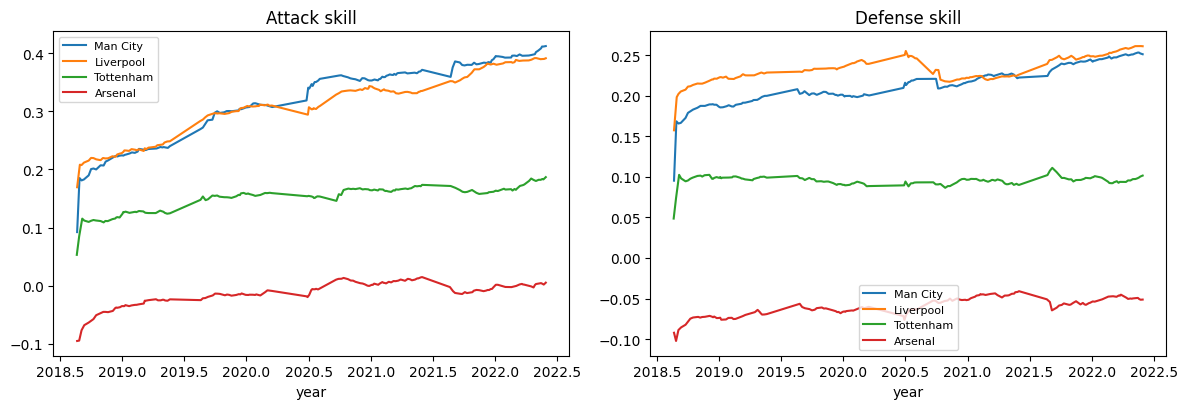

In [7]:
m = bp_model(EXKF_ab[1], EXKF_ab[2], EXKF_ab[0] - EXKF_ab[1], 0.00975808, EXKF_init_cov)
_, final_state, local_seq, _ = compute_factorial_filter(
    m, FactorialEKFConfig(), None, obs_times=match_times,
    obs_values=match_goals, obs_factor_indices=match_idx)
local = np.asarray(local_seq.elem.b)  # (K, 2, 2) -> [slot][att,def]
idx_np = np.asarray(match_idx); yr = np.asarray(match_times) / 365.25 + 2018.6

def team_traj(team):
    pid = name_to_id[team]; ts, att, dfn = [], [], []
    for k in range(K):
        for slot in range(2):
            if idx_np[k, slot] == pid:
                ts.append(yr[k]); att.append(local[k, slot, 0]); dfn.append(local[k, slot, 1])
    return np.array(ts), np.array(att), np.array(dfn)

clubs = [c for c in ["Man City", "Liverpool", "Tottenham", "Arsenal"] if c in name_to_id]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for c in clubs:
    ts, att, dfn = team_traj(c)
    axes[0].plot(ts, att, lw=1.5, label=c)
    axes[1].plot(ts, dfn, lw=1.5, label=c)
axes[0].set_title("Attack skill"); axes[1].set_title("Defense skill")
for ax in axes:
    ax.set_xlabel("year"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

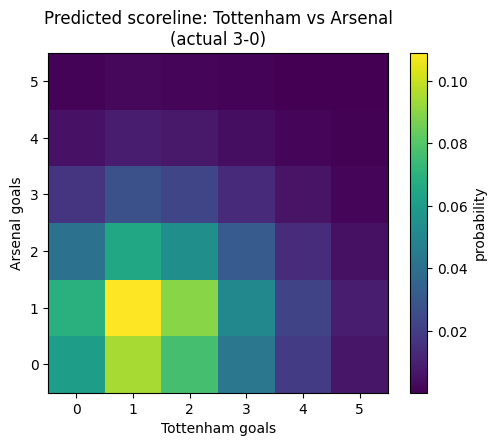

In [8]:
# Predicted scoreline grid for the last fixture between two strong clubs.
pick = None
for k in range(K - 1, -1, -1):
    if id_to_name[int(idx_np[k, 0])] in clubs and id_to_name[int(idx_np[k, 1])] in clubs:
        pick = k; break
grid = np.asarray(bp_out["score_grids"])[pick][:6, :6]
home, away = id_to_name[int(idx_np[pick, 0])], id_to_name[int(idx_np[pick, 1])]
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(grid.T, origin="lower", cmap="viridis")
ax.set_xlabel(f"{home} goals"); ax.set_ylabel(f"{away} goals")
ax.set_title(f"Predicted scoreline: {home} vs {away}\n(actual {int(match_goals[pick,0])}-{int(match_goals[pick,1])})")
plt.colorbar(im, label="probability"); plt.tight_layout(); plt.show()

## 5. Online performance on held-out matches

Using the **self-fitted** bivariate-Poisson parameters, we replay the held-out test period one match at a time. For the most recent matches we plot the model's **expected goals** for and against the home team (its one-step-ahead scoreline forecast) against the **actual** goals, coloured green where the predicted match outcome (win/draw/loss) was correct.


Held-out (test) online W/D/L accuracy: 53.4% over 380 matches


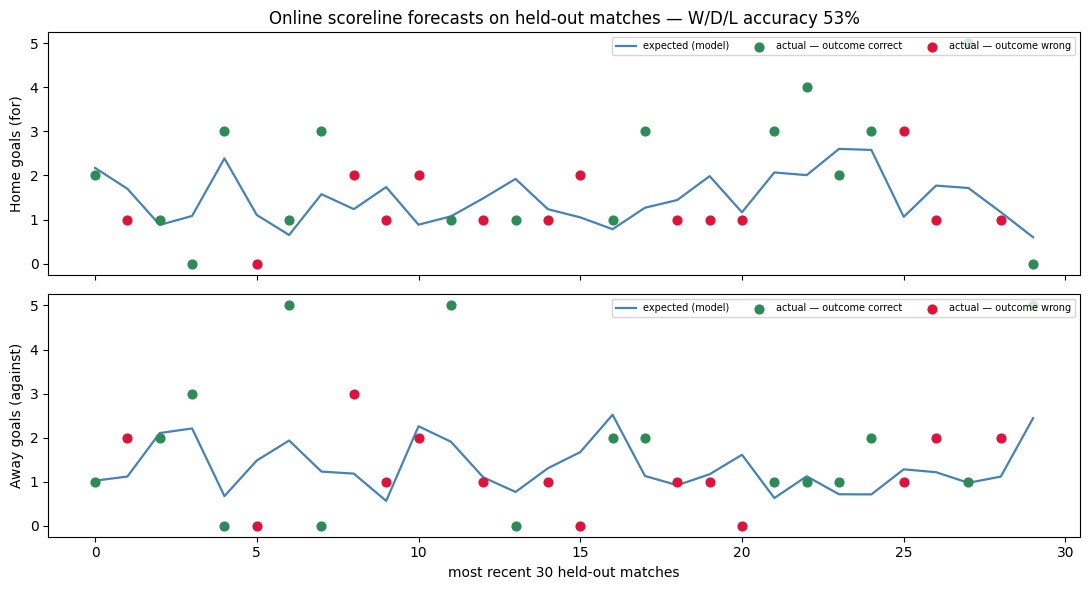

In [9]:
grids = np.asarray(bp_online_out["score_grids"])
gv = np.arange(grids.shape[-1])
exp_home = (grids.sum(2) * gv).sum(1)
exp_away = (grids.sum(1) * gv).sum(1)
wdl_pred = np.asarray(bp_online_out["wdl"]).argmax(1)
actual_out = np.asarray(bp_online_out["outcomes"])
correct = wdl_pred == actual_out
acc = correct[test_start:].mean()
print(f"Held-out (test) online W/D/L accuracy: {acc*100:.1f}% over {K - test_start} matches")

N = 30
sl = slice(K - N, K); x = np.arange(N)
ah = np.asarray(match_goals)[sl, 0]; aa = np.asarray(match_goals)[sl, 1]
eh, ea, cc = exp_home[sl], exp_away[sl], correct[sl]
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, exp, act, ttl in [(axes[0], eh, ah, "Home goals (for)"),
                          (axes[1], ea, aa, "Away goals (against)")]:
    ax.plot(x, exp, color="steelblue", lw=1.6, label="expected (model)")
    ax.scatter(x[cc], act[cc], c="seagreen", s=40, zorder=3, label="actual — outcome correct")
    ax.scatter(x[~cc], act[~cc], c="crimson", s=40, zorder=3, label="actual — outcome wrong")
    ax.set_ylabel(ttl); ax.legend(fontsize=7, ncol=3, loc="upper right")
axes[1].set_xlabel(f"most recent {N} held-out matches")
axes[0].set_title(f"Online scoreline forecasts on held-out matches — W/D/L accuracy {acc*100:.0f}%")
plt.tight_layout(); plt.show()

## 6. Discussion

- **Reproduction.** dynestyx reproduces both EPL results: the outcome-model test NLL (~0.99) and, crucially, the **bivariate-Poisson improvement** to ~0.97 W/D/L NLL — the paper's model-refinement conclusion — on the same data, with the EKF and the particle filter.
- **Independent fit.** A dynestyx PF+Adam fit of the scoreline model recovers sensible attack/defense baselines and a held-out NLL close to the published one, without reusing Duffield et al.'s EM values.
- **Why scorelines help.** Attack/defense skills plus separate home/away scoring rates ($\alpha_h>\alpha_a$ = home advantage) encode information the 3-way outcome model throws away — hence the better match-winner predictions.
- Companion notebooks: `duffield_tennis_wta` (no draws) and `duffield_chess` (heavy draws).

> The factor-marginalized filter is exact on loop-free schedules and a tight approximation on cyclic ones; a league's dense round-robin is mildly cyclic, well within the accurate regime (validated in the test suite).
